In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

#  Load Dataset

In [18]:
df = pd.read_csv("healthcare_patient_records.csv")
df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1001,NaN,Female,South,29.7,154.3,270.2,150.1,1
1,1002,NaN,Male,West,26.6,105.0,193.7,114.6,0
2,1003,46.0,Female,West,NaN,134.5,186.3,117.0,0
3,1004,32.0,Male,North,25.0,122.5,NaN,90.8,0
4,1005,60.0,Male,NaN,31.1,125.8,174.6,119.2,1


#  Basic Dataset Information

In [19]:
print("Shape of Dataset:", df.shape)
print("\nDataset Info:\n")
print(df.info())
print("\nMissing Values:\n")
print(df.isnull().sum())

Shape of Dataset: (500, 9)

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      500 non-null    int64  
 1   age             460 non-null    float64
 2   gender          470 non-null    object 
 3   region          465 non-null    object 
 4   bmi             450 non-null    float64
 5   blood_pressure  460 non-null    float64
 6   cholesterol     450 non-null    float64
 7   glucose         450 non-null    float64
 8   disease_risk    500 non-null    int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 35.3+ KB
None

Missing Values:

patient_id         0
age               40
gender            30
region            35
bmi               50
blood_pressure    40
cholesterol       50
glucose           50
disease_risk       0
dtype: int64


#  Handling Missing Values

In [20]:
num_cols = ['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose']
cat_cols = ['gender', 'region']

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose']
Categorical Columns: ['gender', 'region']


In [21]:
df_simple = df.copy()

num_imputer = SimpleImputer(strategy='mean')
df_simple[num_cols] = num_imputer.fit_transform(df_simple[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df_simple[cat_cols] = cat_imputer.fit_transform(df_simple[cat_cols])

df_simple.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1001,50.030435,Female,South,29.700000,154.3,270.200000,150.1,1
1,1002,50.030435,Male,West,26.600000,105.0,193.700000,114.6,0
2,1003,46.000000,Female,West,26.257778,134.5,186.300000,117.0,0
3,1004,32.000000,Male,North,25.000000,122.5,189.982667,90.8,0
4,1005,60.000000,Male,North,31.100000,125.8,174.600000,119.2,1


# Missing Indicator + Random Sample Imputation

In [22]:
df_random = df.copy()

for col in num_cols:
    df_random[col + "_missing"] = df_random[col].isnull().astype(int)
    random_sample = df_random[col].dropna().sample(
        df_random[col].isnull().sum(),
        random_state=42,
        replace=True
    )
    random_sample.index = df_random[df_random[col].isnull()].index
    df_random.loc[df_random[col].isnull(), col] = random_sample

df_random.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,age_missing,bmi_missing,blood_pressure_missing,cholesterol_missing,glucose_missing
0,1001,74.0,Female,South,29.7,154.3,270.2,150.1,1,1,0,0,0,0
1,1002,66.0,Male,West,26.6,105.0,193.7,114.6,0,1,0,0,0,0
2,1003,46.0,Female,West,26.4,134.5,186.3,117.0,0,0,1,0,0,0
3,1004,32.0,Male,North,25.0,122.5,126.9,90.8,0,0,0,0,1,0
4,1005,60.0,Male,NaN,31.1,125.8,174.6,119.2,1,0,0,0,0,0


# KNN Imputation

In [23]:
df_knn = df.copy()
df_knn['gender'] = LabelEncoder().fit_transform(df_knn['gender'].astype(str))
df_knn['region'] = LabelEncoder().fit_transform(df_knn['region'].astype(str))

knn_imputer = KNNImputer(n_neighbors=5)
df_knn[df_knn.columns] = knn_imputer.fit_transform(df_knn)

df_knn.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1001.0,48.0,0.0,2.0,29.70,154.3,270.20,150.1,1.0
1,1002.0,43.4,1.0,3.0,26.60,105.0,193.70,114.6,0.0
2,1003.0,46.0,0.0,3.0,26.78,134.5,186.30,117.0,0.0
3,1004.0,32.0,1.0,1.0,25.00,122.5,158.88,90.8,0.0
4,1005.0,60.0,1.0,4.0,31.10,125.8,174.60,119.2,1.0


# MICE Algorithm

In [24]:
df_mice = df.copy()
df_mice['gender'] = LabelEncoder().fit_transform(df_mice['gender'].astype(str))
df_mice['region'] = LabelEncoder().fit_transform(df_mice['region'].astype(str))

mice_imputer = IterativeImputer(random_state=42)
df_mice[df_mice.columns] = mice_imputer.fit_transform(df_mice)

df_mice.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1001.0,50.673814,0.0,2.0,29.700000,154.3,270.200000,150.1,1.0
1,1002.0,43.915364,1.0,3.0,26.600000,105.0,193.700000,114.6,0.0
2,1003.0,46.000000,0.0,3.0,24.377662,134.5,186.300000,117.0,0.0
3,1004.0,32.000000,1.0,1.0,25.000000,122.5,190.649143,90.8,0.0
4,1005.0,60.000000,1.0,4.0,31.100000,125.8,174.600000,119.2,1.0


#  Handling Outliers

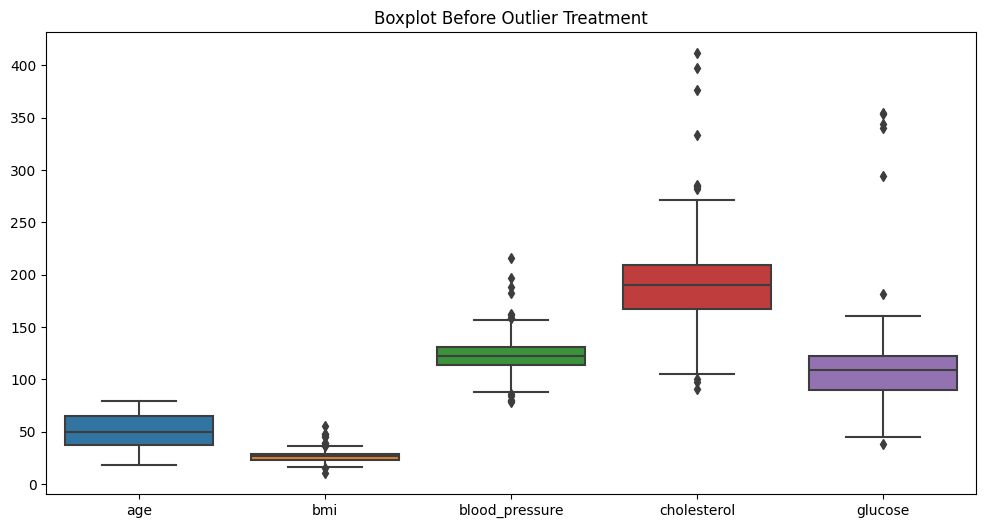

In [25]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_simple[num_cols])
plt.title("Boxplot Before Outlier Treatment")
plt.show()

In [26]:
z_scores = np.abs(stats.zscore(df_simple[num_cols]))
outliers_z = (z_scores > 3).sum(axis=0)

print("Outliers using Z-Score Method:")
print(pd.Series(outliers_z, index=num_cols))

Outliers using Z-Score Method:
age               0
bmi               6
blood_pressure    4
cholesterol       4
glucose           5
dtype: int64


In [27]:
for col in num_cols:
    Q1 = df_simple[col].quantile(0.25)
    Q3 = df_simple[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_simple[(df_simple[col] < lower) | (df_simple[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
bmi: 12 outliers
blood_pressure: 13 outliers
cholesterol: 11 outliers
glucose: 7 outliers


# Winsorization Technique

In [28]:
df_final = df_simple.copy()

for col in num_cols:
    lower = df_final[col].quantile(0.01)
    upper = df_final[col].quantile(0.99)
    df_final[col] = np.where(df_final[col] < lower, lower, df_final[col])
    df_final[col] = np.where(df_final[col] > upper, upper, df_final[col])

df_final.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1001,50.030435,Female,South,29.700000,154.3,270.200000,150.1,1
1,1002,50.030435,Male,West,26.600000,105.0,193.700000,114.6,0
2,1003,46.000000,Female,West,26.257778,134.5,186.300000,117.0,0
3,1004,32.000000,Male,North,25.000000,122.5,189.982667,90.8,0
4,1005,60.000000,Male,North,31.100000,125.8,174.600000,119.2,1


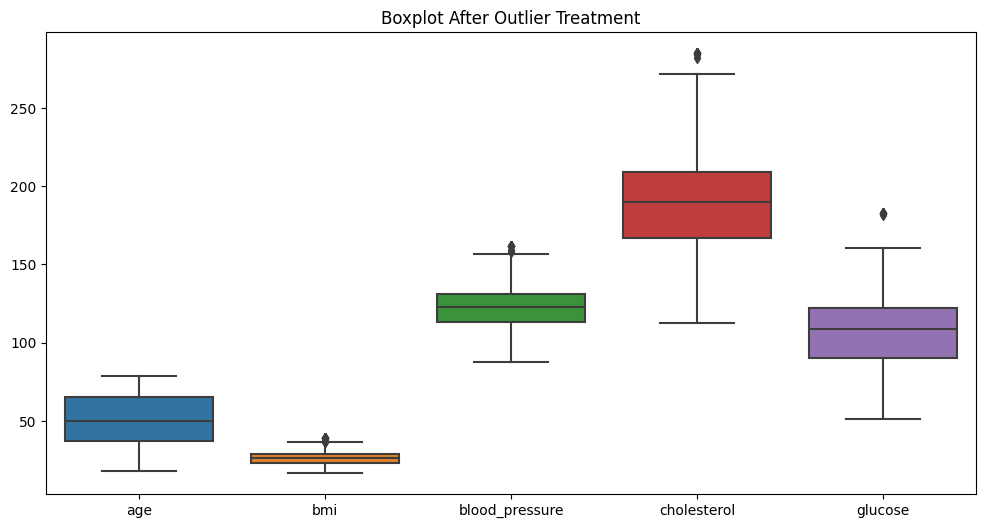

In [29]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_final[num_cols])
plt.title("Boxplot After Outlier Treatment")
plt.show()

#  Final Clean Dataset

In [30]:
print("Final Missing Values:")
print(df_final.isnull().sum())

df_final.to_csv("final_clean_healthcare_dataset.csv", index=False)
print("Final cleaned dataset saved successfully.")

Final Missing Values:
patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64
Final cleaned dataset saved successfully.
